# MNIST: Autoencoder と VAE の比較

このノートブックでは、通常の Convolutional Autoencoder と Variational Autoencoder (VAE) を同じ条件で学習し、以下を比較します。

- 学習時の損失
- 再構成画像
- 潜在空間
- ランダムサンプリング画像


In [1]:
# セル1: ライブラリとデバイス設定
import ssl
ssl._create_default_https_context = ssl._create_unverified_context  # macOS SSL fix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np


device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: mps


/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_90418/1082055590.py:21: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_90418/1082055590.py:21: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_90418/1082055590.py:21: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_90418/1082055590.py:21: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_90418/1082055590.py:21: UserWarning: Glyph 30011 (\N{CJK UNIFIED IDEOGRAPH-753B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipyk

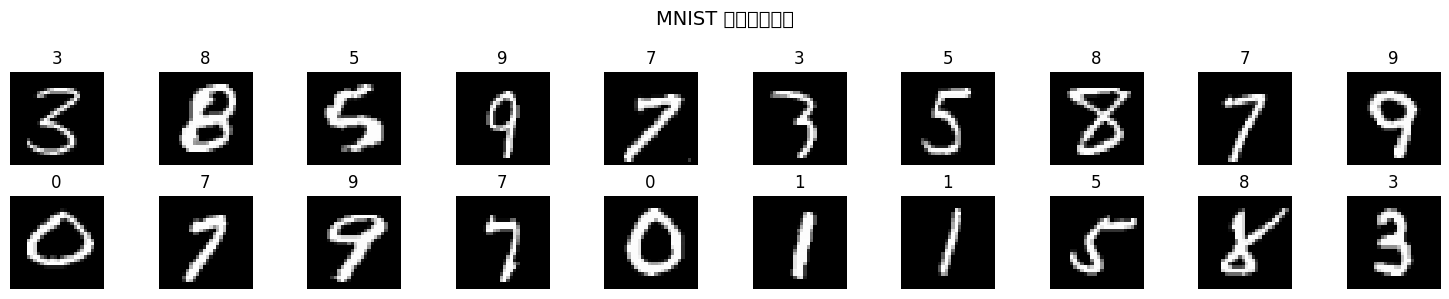

Train: 60000 samples, Test: 10000 samples


In [2]:
# セル2: データ準備
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

BATCH_SIZE = 256
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    ax = axes[i // 10, i % 10]
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(labels[i].item())
    ax.axis('off')
plt.suptitle('MNIST サンプル画像', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Train: {len(train_dataset)} samples, Test: {len(test_dataset)} samples')


In [3]:
# セル3: AE と VAE のモデル定義
LATENT_DIM = 2

class Encoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 14 -> 7
            nn.ReLU(),
        )
        self.fc = nn.Linear(64 * 7 * 7, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),   # 14 -> 28
            nn.Sigmoid(),
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 64, 7, 7)
        return self.deconv(x)


class Autoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)
        self.decoder = Decoder(latent_dim)

    def encode(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar, z


ae_model = Autoencoder(latent_dim=LATENT_DIM).to(device)
vae_model = VariationalAutoencoder(latent_dim=LATENT_DIM).to(device)

print(ae_model)
print()
print(vae_model)


Autoencoder(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
    )
    (fc): Linear(in_features=3136, out_features=2, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=2, out_features=3136, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): Sigmoid()
    )
  )
)

VariationalAutoencoder(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=3136, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=

In [4]:
# セル4: 損失関数と学習関数
AE_LR = 1e-3
VAE_LR = 1e-3
EPOCHS = 15
BETA = 1.0


def vae_loss_function(recon, x, mu, logvar, beta=1.0):
    recon_loss = F.binary_cross_entropy(recon, x, reduction='sum') / x.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss


def train_ae(model, train_loader, epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse_history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for images, _ in train_loader:
            images = images.to(device)
            optimizer.zero_grad()
            recon, _ = model(images)
            loss = F.mse_loss(recon, images)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        mse_history.append(epoch_loss)
        if epoch % 5 == 0 or epoch == 1:
            print(f'[AE ] Epoch [{epoch:3d}/{epochs}]  MSE: {epoch_loss:.6f}')

    return mse_history


def train_vae(model, train_loader, epochs=10, lr=1e-3, beta=1.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    total_history = []
    recon_history = []
    kl_history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_total = 0.0
        running_recon = 0.0
        running_kl = 0.0

        for images, _ in train_loader:
            images = images.to(device)
            optimizer.zero_grad()
            recon, mu, logvar, _ = model(images)
            total_loss, recon_loss, kl_loss = vae_loss_function(recon, images, mu, logvar, beta=beta)
            total_loss.backward()
            optimizer.step()

            running_total += total_loss.item() * images.size(0)
            running_recon += recon_loss.item() * images.size(0)
            running_kl += kl_loss.item() * images.size(0)

        epoch_total = running_total / len(train_loader.dataset)
        epoch_recon = running_recon / len(train_loader.dataset)
        epoch_kl = running_kl / len(train_loader.dataset)

        total_history.append(epoch_total)
        recon_history.append(epoch_recon)
        kl_history.append(epoch_kl)

        if epoch % 5 == 0 or epoch == 1:
            print(
                f'[VAE] Epoch [{epoch:3d}/{epochs}]  '
                f'Total: {epoch_total:.6f}  Recon: {epoch_recon:.6f}  KL: {epoch_kl:.6f}'
            )

    return total_history, recon_history, kl_history


In [5]:
# セル5: AE と VAE の学習

ae_history = train_ae(ae_model, train_loader, epochs=EPOCHS, lr=AE_LR)
vae_total_history, vae_recon_history, vae_kl_history = train_vae(
    vae_model,
    train_loader,
    epochs=EPOCHS,
    lr=VAE_LR,
    beta=BETA,
)


[AE ] Epoch [  1/15]  MSE: 0.066634
[AE ] Epoch [  5/15]  MSE: 0.048338
[AE ] Epoch [ 10/15]  MSE: 0.045707
[AE ] Epoch [ 15/15]  MSE: 0.044286
[VAE] Epoch [  1/15]  Total: 215.894065  Recon: 207.912364  KL: 7.981700
[VAE] Epoch [  5/15]  Total: 166.580858  Recon: 161.545616  KL: 5.035241
[VAE] Epoch [ 10/15]  Total: 159.417858  Recon: 154.064114  KL: 5.353744
[VAE] Epoch [ 15/15]  Total: 157.123611  Recon: 151.638316  KL: 5.485294


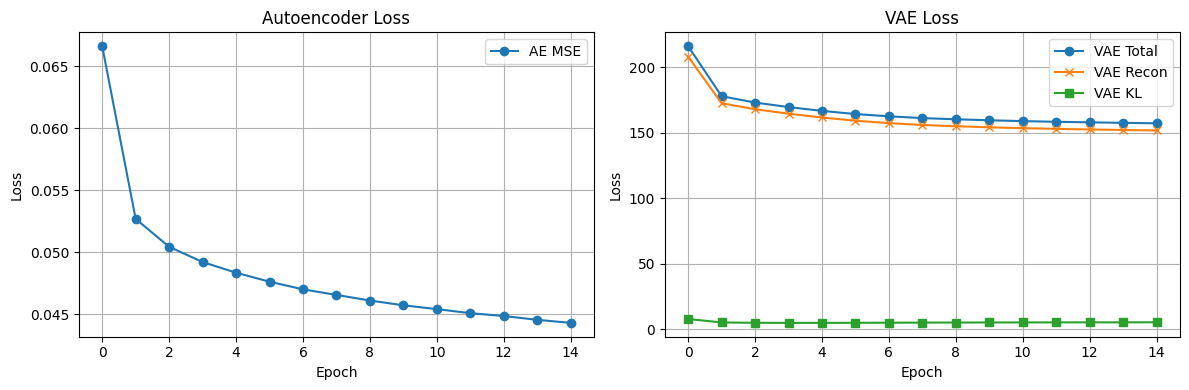

In [6]:
# セル6: 学習曲線の比較
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(ae_history, marker='o', label='AE MSE')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Autoencoder Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(vae_total_history, marker='o', label='VAE Total')
plt.plot(vae_recon_history, marker='x', label='VAE Recon')
plt.plot(vae_kl_history, marker='s', label='VAE KL')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# セル7: 再構成画像の比較
ae_model.eval()
vae_model.eval()

test_imgs, test_labels = next(iter(test_loader))
test_imgs = test_imgs.to(device)

with torch.no_grad():
    ae_recon, _ = ae_model(test_imgs)
    vae_recon, _, _, _ = vae_model(test_imgs)

n = 10
fig, axes = plt.subplots(3, n, figsize=(15, 4.5))
row_labels = ['Original', 'AE Recon', 'VAE Recon']
rows = [test_imgs, ae_recon, vae_recon]

for row_idx, (row_imgs, row_label) in enumerate(zip(rows, row_labels)):
    for col in range(n):
        axes[row_idx, col].imshow(row_imgs[col].detach().cpu().squeeze(), cmap='gray')
        axes[row_idx, col].axis('off')
    axes[row_idx, 0].set_ylabel(row_label, fontsize=11)

plt.suptitle('Reconstruction Comparison', fontsize=14)
plt.tight_layout()
plt.show()


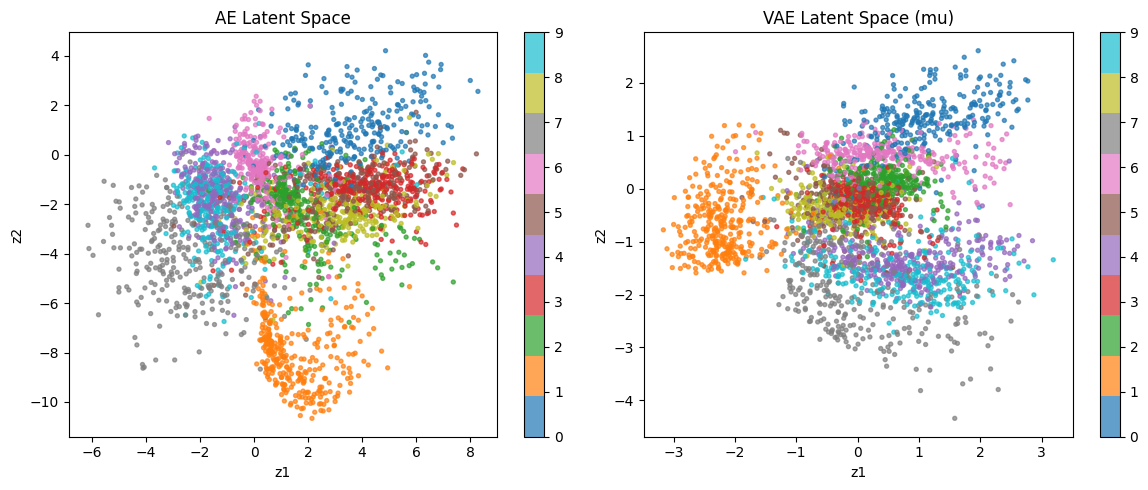

In [7]:
# セル8: 潜在空間の比較

def collect_latents_ae(model, loader, max_points=3000):
    model.eval()
    latents = []
    labels_all = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            _, z = model(images)
            latents.append(z.cpu())
            labels_all.append(labels)
            if sum(x.size(0) for x in latents) >= max_points:
                break
    latents = torch.cat(latents, dim=0)[:max_points]
    labels_all = torch.cat(labels_all, dim=0)[:max_points]
    return latents, labels_all


def collect_latents_vae(model, loader, max_points=3000):
    model.eval()
    latents = []
    labels_all = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            _, mu, _, _ = model(images)
            latents.append(mu.cpu())
            labels_all.append(labels)
            if sum(x.size(0) for x in latents) >= max_points:
                break
    latents = torch.cat(latents, dim=0)[:max_points]
    labels_all = torch.cat(labels_all, dim=0)[:max_points]
    return latents, labels_all


ae_latents, ae_labels = collect_latents_ae(ae_model, test_loader)
vae_latents, vae_labels = collect_latents_vae(vae_model, test_loader)

if LATENT_DIM >= 2:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(ae_latents[:, 0], ae_latents[:, 1], c=ae_labels, cmap='tab10', s=8, alpha=0.7)
    plt.title('AE Latent Space')
    plt.xlabel('z1')
    plt.ylabel('z2')
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.scatter(vae_latents[:, 0], vae_latents[:, 1], c=vae_labels, cmap='tab10', s=8, alpha=0.7)
    plt.title('VAE Latent Space (mu)')
    plt.xlabel('z1')
    plt.ylabel('z2')
    plt.colorbar()

    plt.tight_layout()
    plt.show()
else:
    print('LATENT_DIM >= 2 のときに潜在空間を2次元表示できます。')


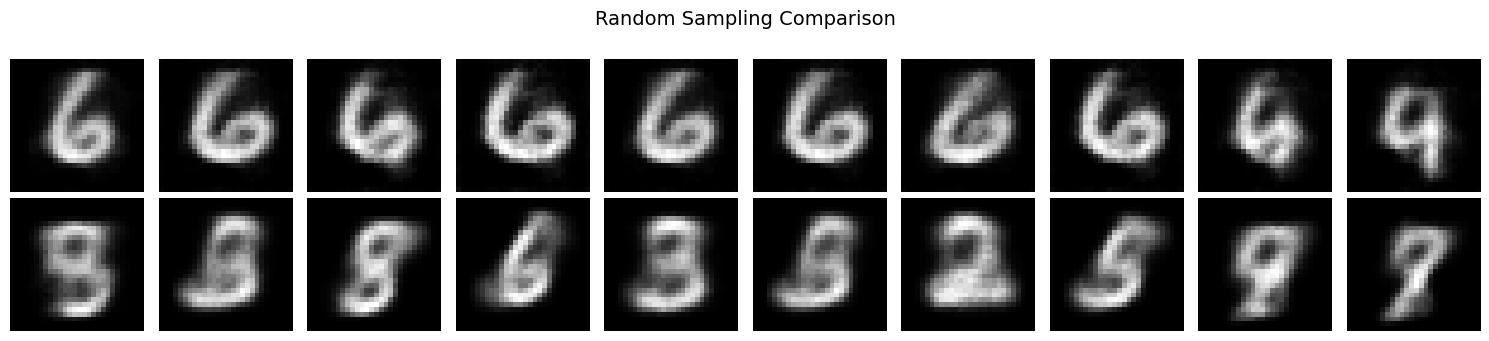

In [8]:
# セル9: ランダムサンプリングの比較
n = 10
random_z = torch.randn(n, LATENT_DIM).to(device)

with torch.no_grad():
    ae_generated = ae_model.decoder(random_z)
    vae_generated = vae_model.decoder(random_z)

fig, axes = plt.subplots(2, n, figsize=(15, 3.5))
for i in range(n):
    axes[0, i].imshow(ae_generated[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(vae_generated[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('AE Sample', fontsize=11)
axes[1, 0].set_ylabel('VAE Sample', fontsize=11)
plt.suptitle('Random Sampling Comparison', fontsize=14)
plt.tight_layout()
plt.show()


In [9]:
# セル10: 最終結果の表示
print('Final comparison')
print(f'AE final MSE      : {ae_history[-1]:.6f}')
print(f'VAE final total   : {vae_total_history[-1]:.6f}')
print(f'VAE final recon   : {vae_recon_history[-1]:.6f}')
print(f'VAE final KL      : {vae_kl_history[-1]:.6f}')


Final comparison
AE final MSE      : 0.044286
VAE final total   : 157.123611
VAE final recon   : 151.638316
VAE final KL      : 5.485294
